# PHYS 449 - Homework 7, Question 2

**Student Name:** Allen Mathew \
**Student ID:** 20964892 \
**Due Date:** Tuesday, November 18, 3:00pm 

*ChatGPT was used to help generate the code*
- - -


2. Apply both PCA and t-SNE for dimensional reduction on the MNIST dataset, reproducing the results shown in lecture.

In [1]:
# Cell 1: imports, RNG, plotting helpers
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from time import time

# sklearn
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Optional: TorchVision for MNIST
try:
    from torchvision import datasets, transforms
    TORCHVISION_AVAILABLE = True
except Exception:
    TORCHVISION_AVAILABLE = False

rng = np.random.default_rng(42)

def stratified_subset(X, y, N, rng=rng):
    """Return a stratified subset of size N (balanced across labels as much as possible)."""
    X = np.asarray(X); y = np.asarray(y)
    classes = np.unique(y)
    per = max(1, N // len(classes))
    idxs = []
    for c in classes:
        cand = np.where(y == c)[0]
        pick = rng.choice(cand, size=min(per, len(cand)), replace=False)
        idxs.append(pick)
    idxs = np.concatenate(idxs)
    # If we need a bit more to reach exactly N, top up randomly
    if len(idxs) < N:
        remaining = np.setdiff1d(np.arange(len(y)), idxs, assume_unique=False)
        extra = rng.choice(remaining, size=min(N - len(idxs), len(remaining)), replace=False)
        idxs = np.concatenate([idxs, extra])
    # If overshot, trim
    if len(idxs) > N:
        idxs = rng.choice(idxs, size=N, replace=False)
    return X[idxs], y[idxs]

def scatter_2d(Z2, y, title):
    plt.figure(figsize=(7, 6))
    sc = plt.scatter(Z2[:,0], Z2[:,1], c=y.astype(int), s=6, alpha=0.8)
    plt.title(title)
    plt.xlabel("dim 1"); plt.ylabel("dim 2")
    plt.tight_layout()
    plt.show()

def describe_labels(y):
    cnt = Counter(y)
    return dict(sorted(cnt.items(), key=lambda kv: int(kv[0])))


(a) First, use PCA to reduce some $784$-dimensional MNIST digits to $2$ dimensions and make a scatter plot where each point’s color corresponds to the digit label. Start with a few thousand digits (e.g. $N = 2000$), and increase N as long as the computational time is reasonable.

In [3]:
# Cell 2: Load MNIST as (X: [N,784], y: [N]) in numpy
def load_mnist_numpy(limit=None, use_torchvision=True, normalize=True):
    """
    Returns X in float32 (0..1 if normalize else 0..255) and y as strings of digits ('0'..'9').
    If limit is not None, returns only the first 'limit' samples (unshuffled).
    """
    X, y = None, None

    if use_torchvision and TORCHVISION_AVAILABLE:
        tfm = transforms.Compose([transforms.ToTensor()])
        ds_train = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
        # stack all train images
        X = np.stack([np.array(ds_train[i][0]).squeeze() for i in range(len(ds_train))], axis=0)  # [N,28,28]
        y = np.array([str(int(ds_train[i][1])) for i in range(len(ds_train))])  # labels as strings for color consistency
    else:
        # Fallback via sklearn OpenML (requires internet)
        from sklearn.datasets import fetch_openml
        mnist = fetch_openml("mnist_784", version=1, as_frame=False)
        X = mnist["data"].reshape(-1, 28, 28)  # [N,28,28]
        y = mnist["target"]

    if limit is not None:
        X = X[:limit]; y = y[:limit]

    X = X.reshape(len(X), -1).astype(np.float32)  # flatten to [N,784]
    if normalize:
        X /= 255.0
    return X, y

# quick smoke check
X_full, y_full = load_mnist_numpy(limit=60000, use_torchvision=True, normalize=True)
print("Loaded:", X_full.shape, "label balance (first 10k):", describe_labels(y_full[:10000]))

Loaded: (60000, 784) label balance (first 10k): {'0': 1001, '1': 1127, '2': 991, '3': 1032, '4': 980, '5': 863, '6': 1014, '7': 1070, '8': 944, '9': 978}


PCA N=2000: explained_var=0.1671, time=0.07s


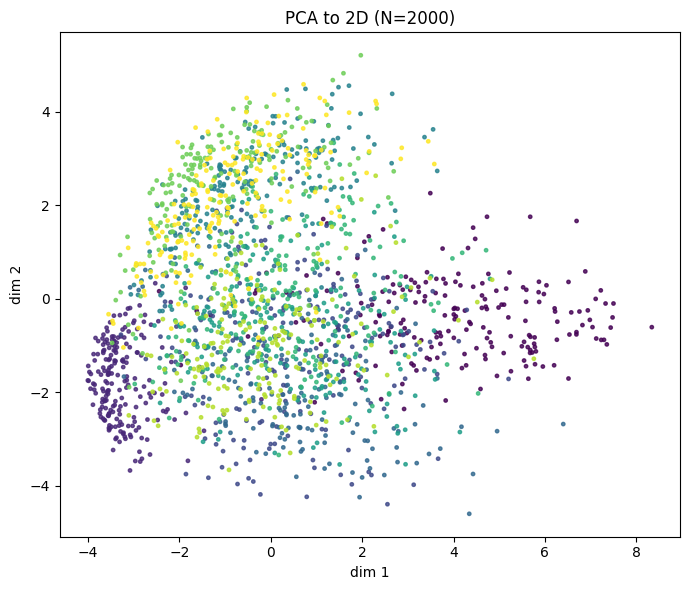

PCA N=5000: explained_var=0.1646, time=0.06s


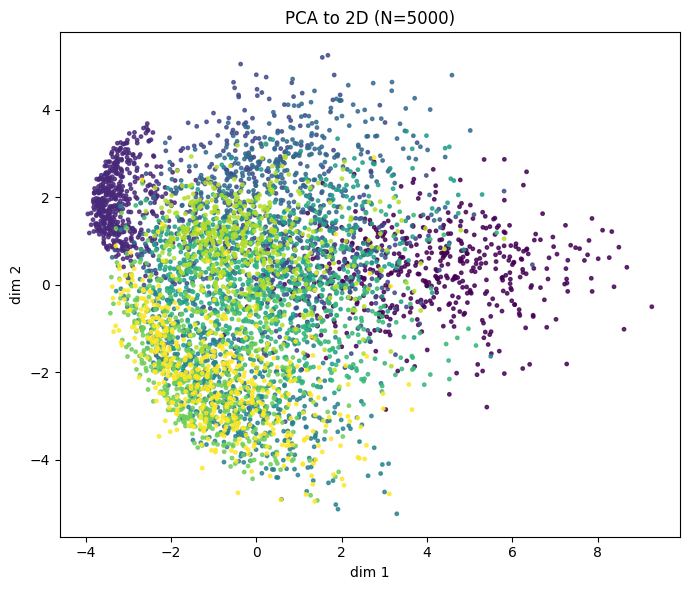

PCA N=10000: explained_var=0.1640, time=0.12s


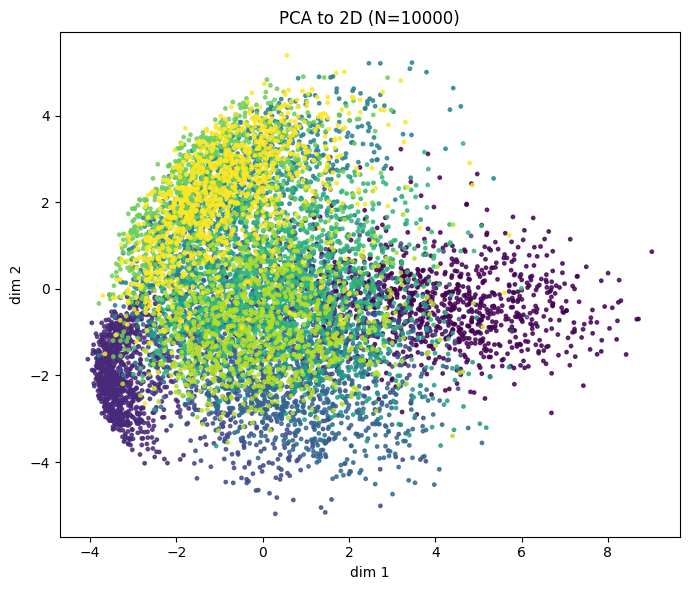

PCA N=20000: explained_var=0.1659, time=0.30s


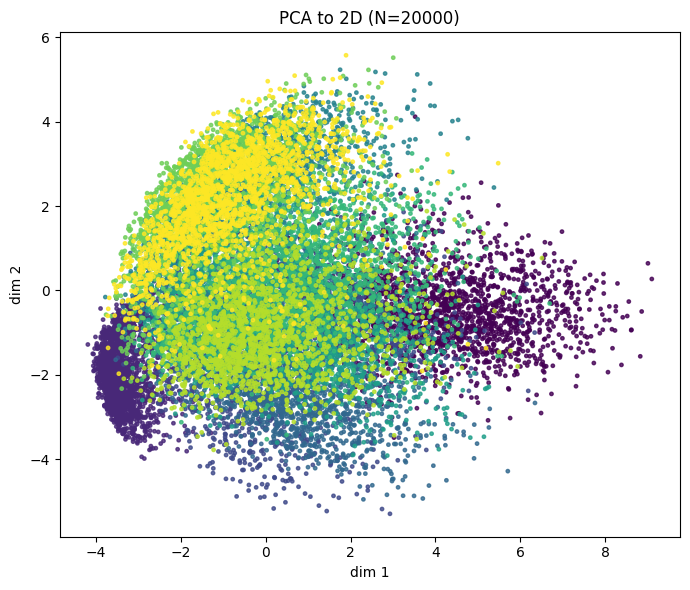

In [4]:
# Cell 3: PCA experiments
def run_pca_at_sizes(X_full, y_full, sizes=(2000, 5000, 10000, 20000)):
    for N in sizes:
        XN, yN = stratified_subset(X_full, y_full, N)
        t0 = time()
        pca = PCA(n_components=2, svd_solver="randomized", random_state=42)
        Z2 = pca.fit_transform(XN)
        t1 = time()
        print(f"PCA N={N}: explained_var={pca.explained_variance_ratio_.sum():.4f}, time={t1-t0:.2f}s")
        scatter_2d(Z2, yN, title=f"PCA to 2D (N={N})")

run_pca_at_sizes(X_full, y_full, sizes=(2000, 5000, 10000, 20000))

(b) Similarly, use t-SNE to reduce the MNIST dataset to $2$ dimensions and illustrate with scatter plots for a few different $N$.

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2000 samples in 0.000s...
[t-SNE] Computed neighbors for 2000 samples in 0.359s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2000
[t-SNE] Computed conditional probabilities for sample 2000 / 2000
[t-SNE] Mean sigma: 2.310430
[t-SNE] KL divergence after 250 iterations with early exaggeration: 75.623169
[t-SNE] KL divergence after 1000 iterations: 1.230744
t-SNE N=2000: time=6.12s (perplexity=30, iters=1000)


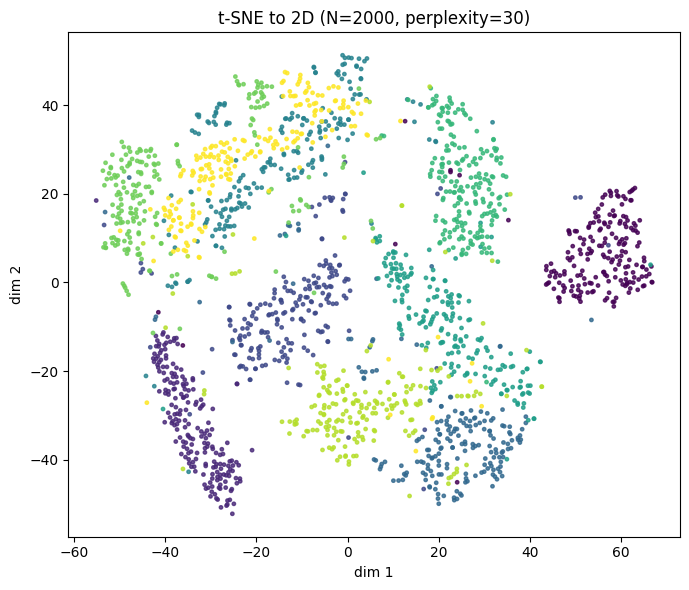

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.000s...
[t-SNE] Computed neighbors for 5000 samples in 0.150s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 1.997164
[t-SNE] KL divergence after 250 iterations with early exaggeration: 81.879868
[t-SNE] KL divergence after 1000 iterations: 1.491778
t-SNE N=5000: time=18.08s (perplexity=30, iters=1000)


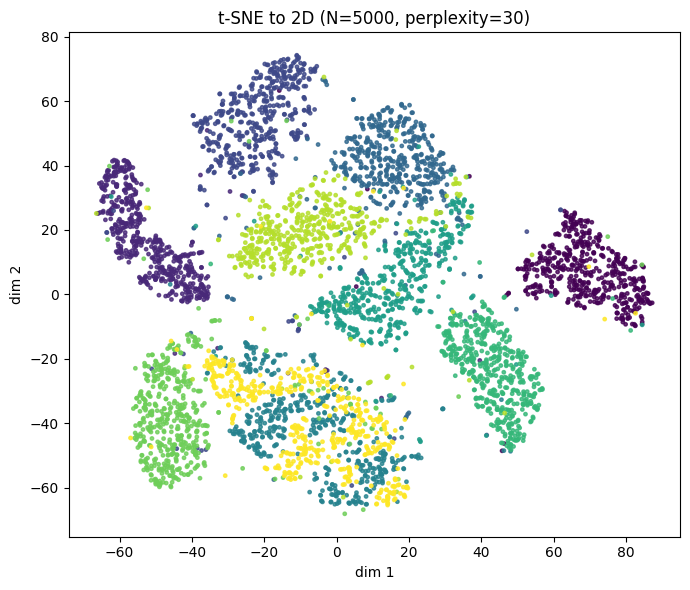

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.000s...
[t-SNE] Computed neighbors for 10000 samples in 0.236s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 1.780055
[t-SNE] KL divergence after 250 iterations with early exaggeration: 86.363350
[t-SNE] KL divergence after 1000 iterations: 1.768519
t-SNE N=10000: time=36.82

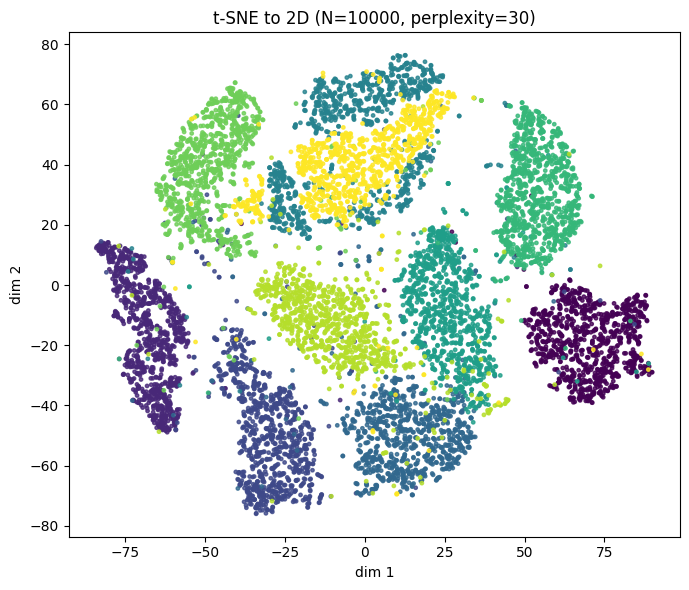

In [5]:
# Cell 4: t-SNE experiments
def run_tsne_at_sizes(X_full, y_full, sizes=(2000, 5000, 10000), perplexity=30, lr=200, iters=1000):
    """
    Sklearn TSNE is O(N^2) in memory/time. Keep N moderate unless you use faster implementations.
    """
    for N in sizes:
        XN, yN = stratified_subset(X_full, y_full, N)
        # Common speed-up: initialize with PCA
        pca2 = PCA(n_components=50, svd_solver="randomized", random_state=42).fit_transform(XN)
        t0 = time()
        tsne = TSNE(
            n_components=2,
            perplexity=perplexity,
            learning_rate=lr,
            n_iter=iters,
            init="pca",
            random_state=42,
            n_jobs=-1,  # requires sklearn >= 1.4; remove if unavailable
            metric="euclidean",
            verbose=1
        )
        Z2 = tsne.fit_transform(pca2)
        t1 = time()
        print(f"t-SNE N={N}: time={t1-t0:.2f}s (perplexity={perplexity}, iters={iters})")
        scatter_2d(Z2, yN, title=f"t-SNE to 2D (N={N}, perplexity={perplexity})")

run_tsne_at_sizes(X_full, y_full, sizes=(2000, 5000, 10000), perplexity=30, lr=200, iters=1000)


(c) Discuss your results. Which digits are well separated by each method? What $N$ do you need to see well-defined clusters in each case? What are the advantages and disadvantages of each method?

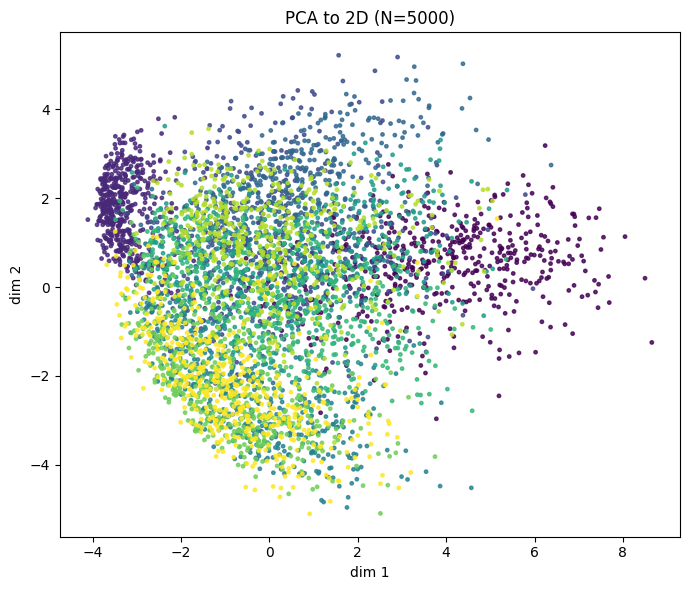

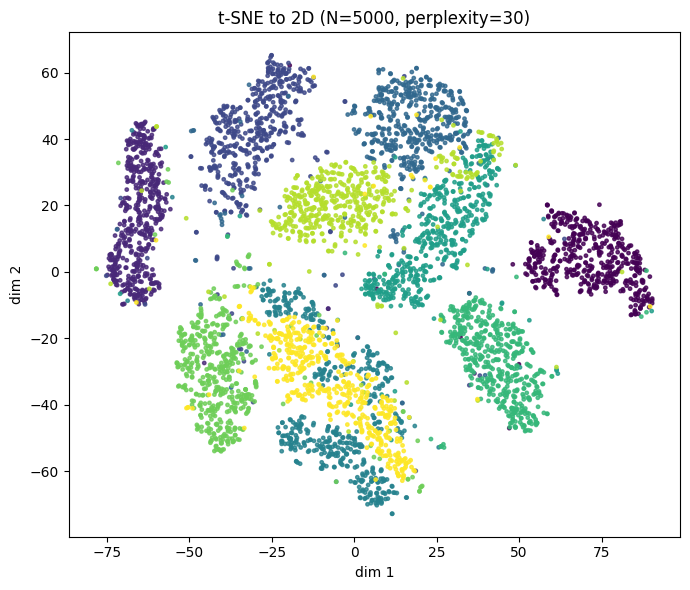

In [6]:
# Cell 5: compare PCA vs t-SNE on the same subset (N=5000 by default)
N = 5000
XN, yN = stratified_subset(X_full, y_full, N)

# PCA -> 2D
pca = PCA(n_components=2, svd_solver="randomized", random_state=42)
Z2_pca = pca.fit_transform(XN)
scatter_2d(Z2_pca, yN, title=f"PCA to 2D (N={N})")

# t-SNE (initialize with PCA to 50D)
XN_50 = PCA(n_components=50, svd_solver="randomized", random_state=42).fit_transform(XN)
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000, init="pca", random_state=42, metric="euclidean")
Z2_tsne = tsne.fit_transform(XN_50)
scatter_2d(Z2_tsne, yN, title=f"t-SNE to 2D (N={N}, perplexity=30)")